In [25]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import folium
from branca.colormap import linear
from branca.colormap import LinearColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime
import warnings
from scipy import stats
from folium.plugins import HeatMap
import matplotlib.cm as cm
import matplotlib.colors as colors
from cartopy.util import add_cyclic_point  # For plotting maps
import hydroeval as he
from matplotlib.colors import ListedColormap
from scipy.stats import ttest_ind
from scipy.stats import linregress

In [26]:
#Define functions

def calculate_model_eval(group):
    # Extract X and y
    X = group['Modelled_scaled'].values.reshape(-1, 1)  # Reshape to ensure X is a 2D array
    y = group['Observed'].values

    # Fit linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Calculate R-squared value
    r2 = model.score(X, y)

    # Calculate correlation coefficient R
    corr_matrix = np.corrcoef(X.flatten(), y)
    r = corr_matrix[0, 1]

    # Get predictions
    y_pred = model.predict(X)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    # Calculate NRMSE (normalized by the range of the observed values)
    nrmse = rmse / (y.max() - y.min())

    # Get slope and intercept
    slope = model.coef_[0]
    intercept = model.intercept_

    # Count number of values
    num_values = len(y)

    return pd.Series({ 'Num_Values': num_values, 'R': r, 'R2': r2, 'NRMSE': nrmse, 'Slope': slope, 'Intercept': intercept})

#Define some other model metrics
def calculate_site_solute_metrics(data):
    # Create an empty DataFrame to store the results
    results_df = pd.DataFrame()

    # Iterate over unique combinations of siteId and Solute
    for (site, var), group in data.groupby(['siteId', 'Variable']):
        # Extract Modelled and Observed data for the current site and solute
        simulations = group['Modelled_scaled'].tolist()
        evaluations = group['Observed'].tolist()

        # Calculate NSE and KGE metrics
        nse = he.evaluator(he.nse, simulations, evaluations)
        kge, r, alpha, beta = he.evaluator(he.kge, simulations, evaluations)

        # Create a DataFrame with the results for the current site and solute
        result = pd.DataFrame({
            'siteId': [site],
            'Variable': [var],
            'NSE': [nse[0]],  # Extracting the scalar value from the array
            'KGE': [kge[0]],  # Extracting the scalar value from the array
            #'R': [r],
            #'Alpha': [alpha],
            #'Beta': [beta]
        })

        # Append the result to the results DataFrame
        results_df = pd.concat([results_df, result], ignore_index=True)

    return results_df

def run_statistics(df, df_name):
    # Count the number of unique sites
    site_count = df.groupby(['Variable'])['siteId'].nunique()
    print(f"Unique site count for {df_name}:\n", site_count)
    
    # For each variable, count the number of observations
    obs_count = df.groupby(['Variable'])['Modelled_scaled'].count()
    print(f"\nObservation count for {df_name}:\n", obs_count)
    
    # For each variable and site, count the number of observations and then average
    obs_site_count = df.groupby(['Variable', 'siteId'])['Modelled_scaled'].count().mean()
    print(f"\nAverage number of observations per site for {df_name}:\n", obs_site_count)


In [27]:
# read in precip filtered Cleaned Paired Modeled Observed
mod_nadp_clean_400 = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Precip Filtered Cleaned Paired Modeled Observed Timeseries FINAL.csv',
                                parse_dates = ['dateOffround'])
mod_nadp_clean_400


,Unnamed: 0,siteId,SamplingInt,dateOnround,dateOffround,latitude,lon,longitude,Modelled,Observed,Variable,Percent_Error,Precip_Percent_Error,year,Error_bin,Error_bin_simple,Month
0,357421,MT97,454.0,2008-10-08,2008-10-16,45.69200,246.25,-113.968000,21.718927,38.35400,Precipitation_mm,76.592515,76.592515,2008,"(75, 100]",3,10
1,337506,MS10,395.0,2007-07-25,2007-08-01,32.30690,270.00,-90.318600,23.683537,8.44400,Precipitation_mm,64.346542,64.346542,2007,"(50, 75]",2,8
2,337510,MS10,399.0,2007-08-22,2007-08-29,32.30690,270.00,-90.318600,20.926037,7.62000,Precipitation_mm,63.586035,63.586035,2007,"(50, 75]",2,8
3,337514,MS10,400.0,2007-08-29,2007-09-05,32.30690,270.00,-90.318600,30.731049,12.70000,Precipitation_mm,58.673717,58.673717,2007,"(50, 75]",2,9
4,337518,MS10,401.0,2007-09-05,2007-09-12,32.30690,270.00,-90.318600,15.338802,14.22400,Precipitation_mm,7.267854,7.267854,2007,"(0, 25]",0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625287,709633,OR10,131.0,2007-04-18,2007-04-23,44.26664,237.50,-122.177000,2.049685,20.17268,WetDep_DOC_mgm2,884.184224,20.753170,2007,"(0, 25]",0,4
625288,709645,OR10,144.0,2007-07-18,2007-07-23,44.26664,237.50,-122.177000,4.770262,11.17600,WetDep_DOC_mgm2,134.284832,34.961172,2007,"(25, 50]",1,7
625289,709651,OR10,155.0,2007-10-03,2007-10-09,44.26664,237.50,-122.177000,4.802452,29.38780,WetDep_DOC_mgm2,511.933201,277.859467,2007,"(275, 300]",11,10
625290,709655,OR10,157.0,2007-10-16,2007-10-23,44.26664,237.50,-122.177000,10.268088,33.01492,WetDep_DOC_mgm2,221.529376,69.261900,2007,"(50, 75]",2,10


In [28]:
# Dictionary of scalars for each variable (this is calculated in the Timeseries Plotting workbook)
scalars = {
    'WetDep_NH4_mgm2': 1.6263834466726403,  
    'WetDep_DOC_mgm2': 2.338358322257403,   
    'WetDep_SO4_mgm2' : 1.595035849862757,
    'WetDep_NO3_mgm2' : 0.7972621012990735,
    'Precipitation_mm' : 1.023427204780364

}

# Apply scalar multiplication and create new modeled columns
mod_nadp_clean_400['Modelled_scaled'] = mod_nadp_clean_400.apply(lambda row: row['Modelled'] * scalars[row['Variable']], axis=1)
mod_nadp_clean_400['Percent_Error_scaled'] = ((abs(mod_nadp_clean_400['Modelled_scaled'] - mod_nadp_clean_400['Observed']))/(mod_nadp_clean_400['Modelled_scaled']))*100
mod_nadp_clean_400

,Unnamed: 0,siteId,SamplingInt,dateOnround,dateOffround,latitude,lon,longitude,Modelled,Observed,Variable,Percent_Error,Precip_Percent_Error,year,Error_bin,Error_bin_simple,Month,Modelled_scaled,Percent_Error_scaled
0,357421,MT97,454.0,2008-10-08,2008-10-16,45.69200,246.25,-113.968000,21.718927,38.35400,Precipitation_mm,76.592515,76.592515,2008,"(75, 100]",3,10,22.227741,72.550147
1,337506,MS10,395.0,2007-07-25,2007-08-01,32.30690,270.00,-90.318600,23.683537,8.44400,Precipitation_mm,64.346542,64.346542,2007,"(50, 75]",2,8,24.238376,65.162683
2,337510,MS10,399.0,2007-08-22,2007-08-29,32.30690,270.00,-90.318600,20.926037,7.62000,Precipitation_mm,63.586035,63.586035,2007,"(50, 75]",2,8,21.416276,64.419584
3,337514,MS10,400.0,2007-08-29,2007-09-05,32.30690,270.00,-90.318600,30.731049,12.70000,Precipitation_mm,58.673717,58.673717,2007,"(50, 75]",2,9,31.450991,59.619715
4,337518,MS10,401.0,2007-09-05,2007-09-12,32.30690,270.00,-90.318600,15.338802,14.22400,Precipitation_mm,7.267854,7.267854,2007,"(0, 25]",0,9,15.698147,9.390580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625287,709633,OR10,131.0,2007-04-18,2007-04-23,44.26664,237.50,-122.177000,2.049685,20.17268,WetDep_DOC_mgm2,884.184224,20.753170,2007,"(0, 25]",0,4,4.792899,320.886831
625288,709645,OR10,144.0,2007-07-18,2007-07-23,44.26664,237.50,-122.177000,4.770262,11.17600,WetDep_DOC_mgm2,134.284832,34.961172,2007,"(25, 50]",1,7,11.154582,0.192015
625289,709651,OR10,155.0,2007-10-03,2007-10-09,44.26664,237.50,-122.177000,4.802452,29.38780,WetDep_DOC_mgm2,511.933201,277.859467,2007,"(275, 300]",11,10,11.229854,161.693512
625290,709655,OR10,157.0,2007-10-16,2007-10-23,44.26664,237.50,-122.177000,10.268088,33.01492,WetDep_DOC_mgm2,221.529376,69.261900,2007,"(50, 75]",2,10,24.010470,37.502184


In [29]:
#POST PRECIPITATION FILTERING on scaled data: 
#Determine the chemistry % error threshold below which 90% of the data is retained.

#Total data counts
total_count_chem = mod_nadp_clean_400.groupby('Variable')['Percent_Error_scaled'].count().reset_index()
total_count_chem
total_count_chem['90_perc'] = total_count_chem['Percent_Error_scaled']*0.9
total_count_chem = total_count_chem.rename(columns = {'Percent_Error_scaled' : 'Total_count'})
total_count_chem

# Define the bins
bins = pd.interval_range(start=0, end=2000, freq=5)
bin_labels = [int(interval.left) for interval in bins]
mod_nadp_clean_400['Error_bin_scaled'] = pd.cut(mod_nadp_clean_400['Percent_Error_scaled'],bins=bins,labels=bin_labels,include_lowest=True)

# Replace NaN values with a placeholder (-1)
mod_nadp_clean_400['Error_bin_simple_scaled'] = mod_nadp_clean_400['Error_bin_scaled'].cat.codes

#Group by variable and simple error bin and count
variable_bin_count = mod_nadp_clean_400.groupby(['Variable', 'Error_bin_scaled'])['Percent_Error_scaled'].count().reset_index()
variable_bin_count = variable_bin_count.rename(columns = {'Percent_Error_scaled' : 'Bin_count_scaled'})
all_count = pd.merge(variable_bin_count, total_count_chem, on = 'Variable', how = 'left')
all_count.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Scaled Bin Chem Percent Error Count.csv')
all_count

,Variable,Error_bin_scaled,Bin_count_scaled,Total_count,90_perc
0,Precipitation_mm,"(0, 5]",7628,157886,142097.4
1,Precipitation_mm,"(5, 10]",7758,157886,142097.4
2,Precipitation_mm,"(10, 15]",7842,157886,142097.4
3,Precipitation_mm,"(15, 20]",7673,157886,142097.4
4,Precipitation_mm,"(20, 25]",7796,157886,142097.4
...,...,...,...,...,...
1995,WetDep_SO4_mgm2,"(1975, 1980]",0,154967,139470.3
1996,WetDep_SO4_mgm2,"(1980, 1985]",0,154967,139470.3
1997,WetDep_SO4_mgm2,"(1985, 1990]",0,154967,139470.3
1998,WetDep_SO4_mgm2,"(1990, 1995]",1,154967,139470.3


In [31]:
#After scaling data (determine these thresholds manually): apply custom filter each solute for where 90% of the data is retained 
#precip: 155%, SO42-: 170%, NO3-: 125%, NH4+: 150%, DOC: 340%. 

no3_dat = mod_nadp_clean_400.loc[mod_nadp_clean_400['Variable'] == 'WetDep_NO3_mgm2',]
no3_dat_scaled = no3_dat.loc[no3_dat['Percent_Error_scaled'] <= 124.9999999, ]

so4_dat = mod_nadp_clean_400.loc[mod_nadp_clean_400['Variable'] == 'WetDep_SO4_mgm2',]
so4_dat_scaled = so4_dat.loc[so4_dat['Percent_Error_scaled'] <= 169.9999999, ]

doc_dat = mod_nadp_clean_400.loc[mod_nadp_clean_400['Variable'] == 'WetDep_DOC_mgm2',]
doc_dat_scaled = doc_dat.loc[doc_dat['Percent_Error_scaled'] <= 339.9999999, ]

nh4_dat = mod_nadp_clean_400.loc[mod_nadp_clean_400['Variable'] == 'WetDep_NH4_mgm2',]
nh4_dat_scaled = nh4_dat.loc[nh4_dat['Percent_Error_scaled'] <= 149.9999999, ]

precip_dat = mod_nadp_clean_400.loc[mod_nadp_clean_400['Variable'] == 'Precipitation_mm',]
precip_dat_scaled = precip_dat.loc[precip_dat['Percent_Error_scaled'] <= 154.9999999, ]

mod_nadp_clean_chem_scaled = pd.concat([precip_dat_scaled, no3_dat_scaled, so4_dat_scaled, doc_dat_scaled, nh4_dat_scaled])
mod_nadp_clean_chem_scaled

,Unnamed: 0,siteId,SamplingInt,dateOnround,dateOffround,latitude,lon,longitude,Modelled,Observed,...,Percent_Error,Precip_Percent_Error,year,Error_bin,Error_bin_simple,Month,Modelled_scaled,Percent_Error_scaled,Error_bin_scaled,Error_bin_simple_scaled
0,357421,MT97,454.0,2008-10-08,2008-10-16,45.6920,246.25,-113.9680,21.718927,38.354000,...,76.592515,76.592515,2008,"(75, 100]",3,10,22.227741,72.550147,"(70, 75]",14
1,337506,MS10,395.0,2007-07-25,2007-08-01,32.3069,270.00,-90.3186,23.683537,8.444000,...,64.346542,64.346542,2007,"(50, 75]",2,8,24.238376,65.162683,"(65, 70]",13
2,337510,MS10,399.0,2007-08-22,2007-08-29,32.3069,270.00,-90.3186,20.926037,7.620000,...,63.586035,63.586035,2007,"(50, 75]",2,8,21.416276,64.419584,"(60, 65]",12
3,337514,MS10,400.0,2007-08-29,2007-09-05,32.3069,270.00,-90.3186,30.731049,12.700000,...,58.673717,58.673717,2007,"(50, 75]",2,9,31.450991,59.619715,"(55, 60]",11
4,337518,MS10,401.0,2007-09-05,2007-09-12,32.3069,270.00,-90.3186,15.338802,14.224000,...,7.267854,7.267854,2007,"(0, 25]",0,9,15.698147,9.390580,"(5, 10]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622827,289898,MI52,517.0,2010-01-06,2010-01-13,42.4164,276.25,-83.9019,1.429424,0.883666,...,38.180282,20.448764,2010,"(0, 25]",0,1,2.324792,61.989457,"(60, 65]",12
622828,287794,MI51,929.0,2017-11-08,2017-11-15,43.6135,276.25,-83.3599,1.563917,2.457450,...,57.134328,77.356382,2017,"(75, 100]",3,11,2.543528,3.384206,"(0, 5]",0
622829,289890,MI52,515.0,2009-12-23,2009-12-30,42.4164,276.25,-83.9019,1.552103,2.520188,...,62.372487,43.668263,2009,"(25, 50]",1,12,2.524314,0.163466,"(0, 5]",0
622830,581043,TX04,1104.0,2021-06-24,2021-06-30,29.3025,256.25,-103.1781,4.345282,2.114550,...,51.336872,322.112162,2021,"(300, 325]",12,6,7.067094,70.078933,"(70, 75]",14


In [32]:
mod_nadp_clean_chem_scaled.groupby('Variable')['Percent_Error_scaled'].max() #make sure it worked

Variable
Precipitation_mm    154.989372
WetDep_DOC_mgm2     337.604503
WetDep_NH4_mgm2     149.987167
WetDep_NO3_mgm2     124.993777
WetDep_SO4_mgm2     169.987867
Name: Percent_Error_scaled, dtype: float64

In [33]:
doc_dat= mod_nadp_clean_chem_scaled.loc[mod_nadp_clean_chem_scaled.Variable == 'WetDep_DOC_mgm2',]
doc_sites = doc_dat[['siteId', 'latitude', 'longitude']].drop_duplicates()
doc_sites.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/DOC_wetdep_compiled_passed cleaning.csv')
doc_sites

,siteId,latitude,longitude
622833,TF,43.108000,-70.950000
623102,TN11,35.664500,-83.590300
623161,TX03,28.466700,-97.706900
623166,WA14,47.859700,-123.932500
623452,WV05,38.879400,-80.847600
623513,WY08,44.916600,-110.420300
623569,SR,44.483333,-72.166667
623572,MN16,47.531100,-93.468600
623578,MN32,48.413200,-92.830500
623591,MT05,48.510200,-113.997000


In [34]:
#Determine statistics for each variable
#Print some statistics on how each of these dataframes compare to one another (excluding DOC because considerably less data here)
chem_filter = mod_nadp_clean_chem_scaled.loc[mod_nadp_clean_chem_scaled['Variable'] != 'WetDep_DOC_mgm2',]
run_statistics(chem_filter, "mod_nadp_clean_chem_scaled")

Unique site count for mod_nadp_clean_chem_scaled:
 Variable
Precipitation_mm    314
WetDep_NH4_mgm2     312
WetDep_NO3_mgm2     312
WetDep_SO4_mgm2     312
Name: siteId, dtype: int64

Observation count for mod_nadp_clean_chem_scaled:
 Variable
Precipitation_mm    141478
WetDep_NH4_mgm2     139275
WetDep_NO3_mgm2     138877
WetDep_SO4_mgm2     139012
Name: Modelled_scaled, dtype: int64

Average number of observations per site for mod_nadp_clean_chem_scaled:
 446.9136


In [35]:
# group by site and count number of observations
site_obs_precip = mod_nadp_clean_400.groupby(['siteId', 'Variable'])['Modelled_scaled'].count().reset_index()
site_obs_precip = site_obs_precip.rename(columns = {'Modelled_scaled': 'Precip_filter_count'})

site_obs_chem = mod_nadp_clean_chem_scaled.groupby(['siteId', 'Variable'])['Modelled_scaled'].count().reset_index()
site_obs_chem = site_obs_chem.rename(columns = {'Modelled_scaled': 'Chem_filter_count_scaled'})

site_obs = pd.merge(site_obs_precip, site_obs_chem, on = ['siteId', 'Variable'], how = 'outer')
site_obs['Difference_count'] = site_obs['Precip_filter_count'] -  site_obs['Chem_filter_count_scaled']  
lat_lon = mod_nadp_clean_400[['siteId', 'latitude', 'longitude']].drop_duplicates()
site_obs_all = pd.merge(site_obs, lat_lon, on = ['siteId'], how = 'left')

site_obs_all.dropna(inplace = True)
site_obs_all = site_obs_all[site_obs_all['Precip_filter_count'] != 0]
site_obs_all.drop_duplicates(inplace = True)
site_obs_all

,siteId,Variable,Precip_filter_count,Chem_filter_count_scaled,Difference_count,latitude,longitude
0,AL02,Precipitation_mm,226,171,55,30.7907,-87.8498
1,AL02,WetDep_NH4_mgm2,226,177,49,30.7907,-87.8498
2,AL02,WetDep_NO3_mgm2,226,175,51,30.7907,-87.8498
3,AL02,WetDep_SO4_mgm2,226,142,84,30.7907,-87.8498
4,AL03,Precipitation_mm,183,139,44,32.9034,-87.2499
...,...,...,...,...,...,...,...
1282,WY98,WetDep_SO4_mgm2,595,576,19,43.2227,-109.9917
1283,WY99,Precipitation_mm,529,472,57,43.8730,-104.1917
1284,WY99,WetDep_NH4_mgm2,529,509,20,43.8730,-104.1917
1285,WY99,WetDep_NO3_mgm2,528,490,38,43.8730,-104.1917


In [38]:
#PLot a map of number of datapoints removed per site.
var = 'Difference_count'

var_plot = site_obs_all.loc[site_obs_all.Variable == 'WetDep_SO4_mgm2']
map_center = [var_plot['latitude'].mean(), var_plot['longitude'].mean()]
mymap = folium.Map(location=map_center, zoom_start=4, tiles='CartoDB positron')

# Define Viridis colormap
colormap = linear.viridis.scale(0, var_plot['Difference_count'].max())

# Add points to the map and color them by the value
for i in range(len(var_plot)):
    folium.CircleMarker(
        location=[var_plot.iloc[i]['latitude'], var_plot.iloc[i]['longitude']],
        radius=6,
        color=None,  # Set color to None to remove the outline
        fill=True,
        fill_color=colormap(var_plot.iloc[i][var]),
        fill_opacity=1,
        popup=f'Site ID: {var_plot.iloc[i]["siteId"]}<br>Value: {var_plot.iloc[i][var]}'
    ).add_to(mymap)

# Add legend
colormap.add_to(mymap)

# Display the map
mymap

In [39]:
#Now do the same calculation for temporal
mod_nadp_clean_400['Year'] = mod_nadp_clean_400['dateOffround'].dt.year
site_obs_precip = mod_nadp_clean_400.groupby(['Variable', 'Year'])['Modelled_scaled'].count().reset_index()
site_obs_precip = site_obs_precip.rename(columns = {'Modelled_scaled': 'Precip_filter_count'})
site_obs_precip

mod_nadp_clean_chem_scaled['Year'] = mod_nadp_clean_chem_scaled['dateOffround'].dt.year
site_obs_chem = mod_nadp_clean_chem_scaled.groupby([ 'Variable', 'Year'])['Modelled_scaled'].count().reset_index()
site_obs_chem = site_obs_chem.rename(columns = {'Modelled_scaled': 'Chem_filter_count_scaled'})

site_obs_all = pd.merge(site_obs_precip, site_obs_chem, on = [ 'Variable', 'Year'], how = 'outer')
site_obs_all['Difference_count'] = site_obs_all['Precip_filter_count'] -  site_obs_all['Chem_filter_count_scaled']  

site_obs_all.dropna(inplace = True)
site_obs_all = site_obs_all[site_obs_all['Precip_filter_count'] != 0]
site_obs_all = site_obs_all.loc[site_obs_all.Year < 2023,]

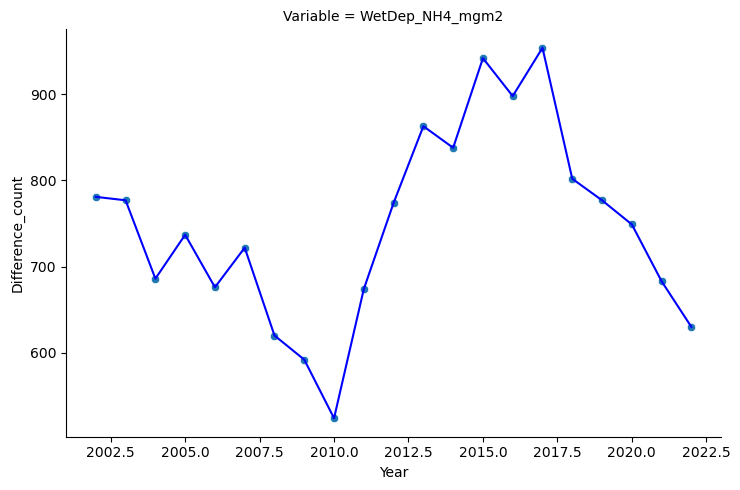

In [42]:
# Plot the scatter points with facets
g = sns.relplot(
    data=site_obs_all.loc[site_obs_all.Variable == 'WetDep_NH4_mgm2',],
    x="Year", y='Difference_count', palette='viridis', kind='scatter', col='Variable', col_wrap =1,
    height=5, aspect=1.5, facet_kws=dict(sharex=False, sharey=False),
)

# Add a lineplot to each facet
for ax, variable in zip(g.axes.flat, g.col_names):
    sns.lineplot(
        data=site_obs_all[site_obs_all.Variable == variable],
        x="Year", y='Difference_count', color='blue', ax=ax
)

# Add a shared title for the entire plot
#g.fig.suptitle('Difference in observations per year before and after 90% data retention precipitation error filter', y=1.02)
plt.show()

In [14]:
#Calculate model evaluation metrics on the scaled data
warnings.filterwarnings("ignore") # Suppress specific warning types

model_eval = mod_nadp_clean_chem_scaled.groupby(['siteId','latitude', 'longitude', 'lon', 'Variable']).apply(calculate_model_eval).reset_index()
he_metrics_df = calculate_site_solute_metrics(mod_nadp_clean_chem_scaled)
fit_df_all = pd.merge(model_eval, he_metrics_df, on=['siteId', 'Variable'])

#remove sites where metrics were calcualted with less than 3 values
fit_df = fit_df_all.loc[fit_df_all['Num_Values'] > 3,]
fit_df_sites = fit_df.groupby('Variable')['siteId'].count()

#Subset focus metrics
fit_df = fit_df[['siteId', 'latitude', 'longitude', 'lon', 'Variable', 'R2', 'NRMSE', 'NSE', 'KGE', 'Num_Values']]
fit_df.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/SCALED Model Eval Metrics_r2_nrmse_nse_kge.csv')
fit_df


,siteId,latitude,longitude,lon,Variable,R2,NRMSE,NSE,KGE,Num_Values
0,AL02,30.7907,-87.8498,272.50,Precipitation_mm,0.506260,0.114147,0.471958,0.601872,171.0
1,AL02,30.7907,-87.8498,272.50,WetDep_NH4_mgm2,0.200049,0.112519,-0.146503,0.382558,177.0
2,AL02,30.7907,-87.8498,272.50,WetDep_NO3_mgm2,0.363833,0.096785,0.302656,0.571308,175.0
3,AL02,30.7907,-87.8498,272.50,WetDep_SO4_mgm2,0.527209,0.130882,0.435523,0.454035,142.0
4,AL03,32.9034,-87.2499,272.50,Precipitation_mm,0.501787,0.152070,0.466115,0.690469,139.0
...,...,...,...,...,...,...,...,...,...,...
1270,WY98,43.2227,-109.9917,250.00,WetDep_SO4_mgm2,0.372109,0.081187,-0.293093,0.113914,576.0
1271,WY99,43.8730,-104.1917,256.25,Precipitation_mm,0.402660,0.081412,0.133640,0.536123,472.0
1272,WY99,43.8730,-104.1917,256.25,WetDep_NH4_mgm2,0.410691,0.140007,-1.658741,-0.426085,509.0
1273,WY99,43.8730,-104.1917,256.25,WetDep_NO3_mgm2,0.426509,0.111386,0.045043,0.436767,490.0


In [15]:
sites = fit_df.groupby('Variable')['siteId'].nunique()
vals = fit_df.groupby('Variable')['Num_Values'].sum()

sites
#vals

Variable
Precipitation_mm    313
WetDep_DOC_mgm2      22
WetDep_NH4_mgm2     310
WetDep_NO3_mgm2     310
WetDep_SO4_mgm2     311
Name: siteId, dtype: int64

In [16]:
fit_df_DOC = fit_df.loc[fit_df.Variable == 'WetDep_DOC_mgm2',]
fit_df_DOC['siteId'].unique()

array(['AZ03', 'CA96', 'CO90', 'GA09', 'IA23', 'LA30', 'ME09', 'MN16',
       'MN32', 'MT05', 'ND00', 'NH02', 'NV05', 'OK00', 'OR10', 'SR', 'TF',
       'TN11', 'TX03', 'WA14', 'WV05', 'WY08'], dtype=object)

In [17]:
#Percent of sites with the Poor, Acceptable, and Good category:
fit_df_KGE = fit_df[['siteId', 'Variable', 'KGE', 'Num_Values']]
fit_df_KGE['KGE_class'] = np.where(fit_df_KGE.KGE < 0.4, 'Poor', 'Acceptable')

fit_df_KGE_site_class = fit_df_KGE.groupby(['Variable','KGE_class'])['siteId'].nunique()
fit_df_KGE_site_class

#fit_df_KGE_sumvals = fit_df_KGE.groupby(['Variable','KGE_class'])['Num_Values'].sum()
#fit_df_KGE_sumvals

Variable          KGE_class 
Precipitation_mm  Acceptable    279
                  Poor           34
WetDep_DOC_mgm2   Acceptable      7
                  Poor           15
WetDep_NH4_mgm2   Acceptable    194
                  Poor          116
WetDep_NO3_mgm2   Acceptable    269
                  Poor           41
WetDep_SO4_mgm2   Acceptable    214
                  Poor           97
Name: siteId, dtype: int64

In [18]:
fit_KGE_class = fit_df_KGE[['siteId', 'KGE', 'KGE_class', 'Variable']].drop_duplicates()
clean_df_class = pd.merge(mod_nadp_clean_chem_scaled, fit_df_KGE, on = ['siteId', 'Variable'], how = 'right')
clean_df_class_group = clean_df_class.groupby(['Variable','KGE_class'])[['Modelled_scaled', 'Observed']].mean()
clean_df_class_group['Difference'] = clean_df_class_group['Observed']/ clean_df_class_group['Modelled_scaled']  
#clean_df_class_group['Difference_perc'] = ((clean_df_class_group['Modelled_scaled'] - clean_df_class_group['Observed'])/clean_df_class_group['Modelled_scaled'])*100
clean_df_class_group

Modelled_scaled   Observed  Difference
Variable         KGE_class                                         
Precipitation_mm Acceptable        24.917656  22.396356    0.898815
                 Poor              22.979114  15.761768    0.685917
WetDep_DOC_mgm2  Acceptable        22.830173  20.043422    0.877936
                 Poor              37.541049  24.217660    0.645098
WetDep_NH4_mgm2  Acceptable         6.597490   5.967784    0.904554
                 Poor               6.137266   3.615215    0.589059
WetDep_NO3_mgm2  Acceptable        17.388729  15.132423    0.870243
                 Poor              12.508393   8.316607    0.664882
WetDep_SO4_mgm2  Acceptable        17.745089  16.298762    0.918494
                 Poor              10.875091   6.474985    0.595396

In [19]:
#Convert to long format
fit_df_long = pd.melt(fit_df, id_vars=[ 'siteId', 'latitude', 'lon', 'Variable', 'Num_Values'], 
                      value_vars=['R2', 'NRMSE', 'NSE', 'KGE'], 
                      var_name='Metric', value_name='KGE_Value')

#Subset for just KGE which is focus of main text figure
fit_df_KGE = fit_df_long.loc[fit_df_long['Metric'] == 'KGE',]
fit_df_KGE_chem = fit_df_KGE.loc[fit_df_KGE.Variable != 'Precipitation_mm',]
fit_df_KGE_chem['KGE_Value'].max()

0.7664082221967258

In [20]:
fit_df_KGE.Variable.unique()

array(['Precipitation_mm', 'WetDep_NH4_mgm2', 'WetDep_NO3_mgm2',
       'WetDep_SO4_mgm2', 'WetDep_DOC_mgm2'], dtype=object)

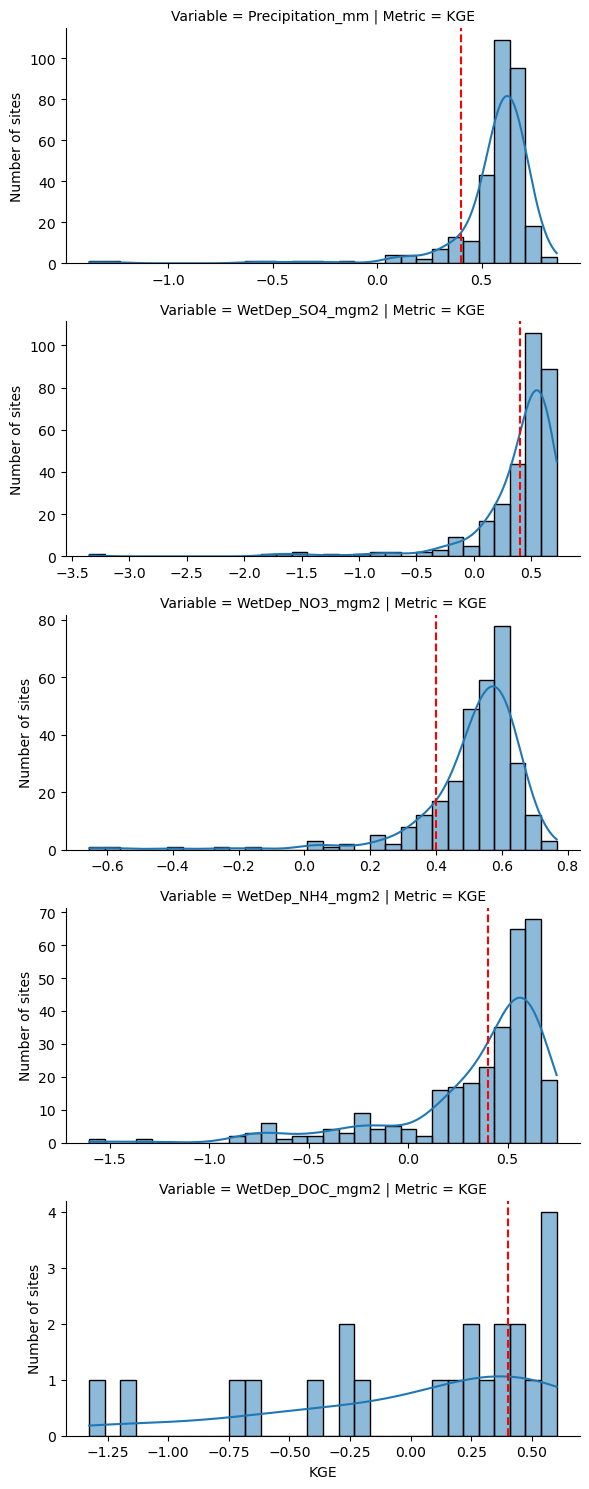

In [21]:
#Histograms of metrics and number of sites
g = sns.FacetGrid(fit_df_KGE, row="Variable", col="Metric", height=3, aspect=2, sharex=False, sharey=False,
                  row_order=['Precipitation_mm', 'WetDep_SO4_mgm2', 'WetDep_NO3_mgm2','WetDep_NH4_mgm2','WetDep_DOC_mgm2'])
g.map(sns.histplot, "KGE_Value", alpha=0.5, bins=30, kde=True)

# Add vertical line and ensure x-axis labels are shown
# Add vertical line and ensure x-axis labels are shown
for ax in g.axes.flat:
    ax.axvline(0.4, color='red', linestyle='--')
    #ax.set_xlim(-1.5, 0.9)
    # Force the x-axis to be labeled for each subplot
    for label in ax.get_xticklabels():
        label.set_visible(True)
    ax.set_xlabel('KGE')
    
# Set common labels and layout
g.set_axis_labels('KGE', 'Number of sites')
g.fig.tight_layout()
#plt.xlim(-1.5, 0.9)
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/SCALED Histogram of KGE.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)
plt.show()

In [22]:
#CURRENTLY PLOTTING A MAP OF FILTERED SITES BY KGE VALUES > 0.35
fit_df_KGE_acc = fit_df.loc[fit_df['KGE'] >= 0.39]
var = 'KGE'

fit_df_var = fit_df_KGE_acc.loc[fit_df_KGE_acc.Variable == 'WetDep_SO4_mgm2']
map_center = [fit_df_var['latitude'].mean(), fit_df_var['lon'].mean()]
mymap = folium.Map(location=map_center, zoom_start=4, tiles='CartoDB positron')

# Define Viridis colormap
colormap = linear.viridis.scale(0.35, 0.8)

# Assuming fit_df_other is the other DataFrame with columns 'latitude', 'lon', 'siteId', and 'KGE'
# Add points from the second DataFrame
for i in range(len(fit_df)):
    folium.CircleMarker(
        location=[fit_df.iloc[i]['latitude'], fit_df.iloc[i]['lon']],
        radius=5,
        color='grey',  # Different color to distinguish from the first set of points
        fill=False,
        weight = 0.4,
    ).add_to(mymap)

# Add points to the map and color them by the value
for i in range(len(fit_df_var)):
    folium.CircleMarker(
        location=[fit_df_var.iloc[i]['latitude'], fit_df_var.iloc[i]['lon']],
        radius=6,
        color=None,  # Set color to None to remove the outline
        fill=True,
        fill_color=colormap(fit_df_var.iloc[i][var]),
        fill_opacity=1,
        popup=f'Site ID: {fit_df_var.iloc[i]["siteId"]}<br>Value: {fit_df_var.iloc[i][var]}'
    ).add_to(mymap)

# Add legend
colormap.add_to(mymap)

# Display the map
mymap